## 1) Importing libraries

In [1]:
import tensorflow as tf
import numpy as np
import onnxruntime as ort
from pathlib import Path
from sklearn.metrics import f1_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
from functions.plots import plot_confusion_matrix
from PIL import Image
import pandas as pd
import os
from time import time

## 2) Reading test set

In [2]:
test = tf.keras.utils.image_dataset_from_directory(
    directory = "./chest-xray/test/",
    labels = "inferred",
    label_mode = "int",
    color_mode = "grayscale",
    batch_size = 32,
    image_size = (200, 200),
    shuffle = False
)

Found 800 files belonging to 4 classes.


## 3) Testing models

### 3.1) Getting predictions

In [5]:
prediction_time = []
size = []

def getting_predict(model_path: str) -> list[float]:
    result = []

    session = ort.InferenceSession(model_path)
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name

    for folder in sorted(Path("./chest-xray/test/").iterdir()):
        if folder.is_dir():

            for archive in sorted(folder.iterdir()):
                img = Image.open(fp = archive)
                img = img.convert("L")  # Garante 1 canal (Grayscale)
                img = img.resize((256, 256))
                        
                img_array = np.array(img, dtype=np.float32)
                
                input_data = np.expand_dims(img_array, axis=0)
                input_data = np.expand_dims(input_data, axis=-1)
                # print(input_data.shape)
                        
                raw_result = session.run([output_name], {input_name: input_data})
                probabilities = raw_result[0][0]

                result.append(probabilities)
    
    return np.array(result)

#### 3.1.1) First model

In [6]:
path = "./models/first_model.onnx"

start_time = time()
first_model_result = getting_predict(model_path = path)
finish_time = time()

prediction_time.append(finish_time - start_time)
size.append(os.path.getsize(filename = path))

#### 3.1.2) Second model

In [7]:
path = "./models/second_model.onnx"

start_time = time()
second_model_result = getting_predict(model_path = path)
finish_time = time()

prediction_time.append(finish_time - start_time)
size.append(os.path.getsize(filename = path))

#### 3.1.3) Third model

In [8]:
path = "./models/third_model.onnx"

start_time = time()
third_model_result = getting_predict(model_path = path)
finish_time = time()

prediction_time.append(finish_time - start_time)
size.append(os.path.getsize(filename = path))

### 3.2) Getting true values

In [9]:
y_true = []

for index, folder in enumerate(sorted(Path("./chest-xray/test/").iterdir())):
    if folder.is_dir():
        y_true += [index] * len(list(folder.iterdir()))

y_true = np.array(y_true)

## 4) Getting better model

### 4.1) Ploting <code>Confusion Matrix</code>

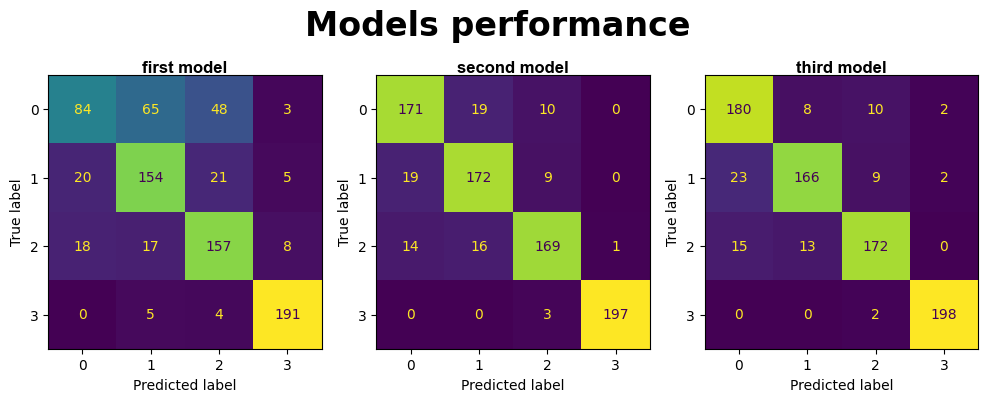

In [10]:
models_dict = [
    {
        "name": "first model",
        "y_pred": first_model_result.argmax(axis = 1),
    },
    {
        "name": "second model",
        "y_pred": second_model_result.argmax(axis = 1),
    },
    {
        "name": "third model",
        "y_pred": third_model_result.argmax(axis = 1)
    }
]

fig, axs = plt.subplots(
    ncols = len(models_dict),
    figsize = (12, 5)
)

for index, model in enumerate(models_dict):

    plot_confusion_matrix(
        ax = axs[index],
        y_true = y_true,
        y_pred = model["y_pred"],
        title = {
            "text": model["name"],
        },
        has_colorbar = False
    )

plt.suptitle(t = "Models performance", fontsize = 24, fontweight = "bold", y = .90)
plt.show()

### 4.2) Getting metrics

In [11]:
models_metrics = {
    model["name"]: [] for model in models_dict
}

for model in models_dict:

    models_metrics[model["name"]].append(
        f1_score(
            y_true = y_true,
            y_pred = model["y_pred"],
            average = "weighted"
        )
    )

    models_metrics[model["name"]].append(
        recall_score(
            y_true = y_true,
            y_pred = model["y_pred"],
            average = "weighted"
        )
    )

    models_metrics[model["name"]].append(
        accuracy_score(
            y_true = y_true,
            y_pred = model["y_pred"],
        )
    )

models_metrics = pd.DataFrame(data = models_metrics, index = ["f1_score", "recall_score", "accuracy_score"]).transpose()
models_metrics.loc[:, "time"] = prediction_time
models_metrics.loc[:, "size (Mb)"] = np.array(size)/(1024*1024)

display(models_metrics)

,f1_score,recall_score,accuracy_score,time,size (Mb)
first model,0.722240,0.73250,0.73250,21.470318,0.095525
second model,0.886536,0.88625,0.88625,36.998107,29.501880
third model,0.894879,0.89500,0.89500,73.331728,77.074040


## 5) Choosing best model

<p align="justify">As we saw previously, the second model - which corresponds to <code>EfficientNetB2</code> base_model - is the most appropriate one because of time and precision. Even though it is not - for a little gap - better than the third model, it is certain have more efficiency than that. And for obvious reasons, even tought the first model has created by scratch, it is not good enough to be comparared to the second and the third models.</p>

<p align="justify">Therefore, we are going to put the second model into production.</p>

In [ ]:
classes = ["Covid-19", "Lung Opacity", "Healthy", "Pneumonia"]
# colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6", "#736e6b"]
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
probabilities = [0.2, 0.1, 0.5, 0.1, 0.5, 0.5]

data = [
    {
        "name": name,
        "value": probabilities[index],
        "color": colors[index]
    } for index, name in enumerate(classes)
]

In [ ]:
data[4]

{'name': 'Pneumonia-Viral', 'value': 0.5, 'color': '#9b59b6'}